In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


ModuleNotFoundError: No module named 'kmodes'

In [ ]:
df = pd.read_stata("../data/HCMST 2017 to 2022 small public version 2.2.dta", convert_categoricals=True)

/var/folders/6j/wxn98q7n083dpm833pdmj1v80000gn/T/ipykernel_30221/4219794960.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../data/HCMST 2017 to 2022 small public version 2.2.dta", convert_categoricals=True)


In [ ]:
df

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,Female,No,Female,No,No,No,No religion,Never,NaN,20210506.0
1,71609,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,Female,No,Female,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0
2,106983,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210429.0
3,121759,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,Male,Male,No,No,No,No,Other Christian religion,Once a week,Yes,20210507.0
4,158083,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,2967957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.594351,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3506,2968357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3507,2968971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.383199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3508,2969933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.197115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Columns: 725 entries, caseid_new to p20_ppp2date2020
dtypes: category(586), datetime64[s](8), float32(46), float64(81), int16(1), int32(1), int8(2)
memory usage: 5.1 MB


In [ ]:
df.columns.tolist()

['caseid_new',
 'w3_Weight',
 'w3_Weight_LGB',
 'w3_combo_weight',
 'w3_attrition_adj_weight',
 'w2_weight_genpop',
 'w2_weight_LGB',
 'w2_combo_weight',
 'w2_attrition_adj_weights',
 'w1_weight_combo',
 'w1_weight_combo_freqwt',
 'w3_xpartner_type',
 'w3_xlast_contact_year',
 'w3_xcohab',
 'w3_xsamesex',
 'w3_xlast_contact_mo',
 'w3_xnamep_present',
 'w3_duration',
 'w3_gen_pop_sample',
 'w3_ppage',
 'w3_ppagecat',
 'w3_ppagect4',
 'w3_ppeduc',
 'w3_ppeducat',
 'w3_ppethm',
 'w3_ppgender',
 'w3_pphhhead',
 'w3_pphhsize',
 'w3_pphouse',
 'w3_ppincimp',
 'w3_real_inc',
 'w3_log_real_inc',
 'w3_ppmarit',
 'w3_ppmsacat',
 'w3_PPREG4',
 'w3_ppreg9',
 'w3_pprent',
 'w3_PPT01',
 'w3_PPT25',
 'w3_PPT612',
 'w3_total_kids_lt13',
 'w3_PPT1317',
 'w3_PPT18OV',
 'w3_ppwork',
 'w3_surveyed',
 'w3_section',
 'w3_partner_type',
 'w3_married',
 'w3_otherdate',
 'w3_coronavirus_effect_combo',
 'w3_corona_effect_combo_reversed',
 'w3_live_w_partner',
 'w3_same_sex_couple',
 'w3_marriage_dp',
 'w3_mar_d

In [ ]:
# CREATIG 'TARGET_BREAKUP' VARIABLE TO INDICATE WHETHER THEY BROKE UP OR NOT FOR CATBOOST   
# import pandas as pd
# import numpy as np

# # 1. Define the status indicating they are still together
# # Note: In HCMST, 1 usually means "Still with the same partner"
# together_val = 1 

# # 2. Identify breakups at Wave 2 or Wave 3
# # We check if they were in the survey but reported NOT being together
# def determine_breakup(row):
#     # If they broke up by Wave 2, it's a breakup (1)
#     if row['w2_section_status'] in [2, 3]: # 2=Broke up, 3=Partner deceased
#         return 1
    
#     # If they were together in W2 but broke up by Wave 3
#     if row['w3_section_status'] in [2, 3]:
#         return 1
    
#     # If they are still together in Wave 3
#     if row['w3_section_status'] == together_val:
#         return 0
    
#     # Otherwise, it's missing data (they dropped out)
#     return np.nan

# # Apply the logic
# df['target_breakup'] = df.apply(determine_breakup, axis=1)

# # 3. Clean up: Remove deaths (Optional but recommended)
# # If a partner died, it's not really a "breakup" in the way OKCupid cares about.
# # You can refine the function above to return NaN if status == 3.


# Part 1 #

In [ ]:
my_features =  [
    'caseid_new',
    'w1_section',
    'w1_ppage',
    'w1_ppgender',
    'w1_ppeducat',
    'w1_partyid7',
    'w1_ppmsacat',
    'w1_same_sex_couple',
    'w1_ppincimp_cat',
    'w1_q32',
    'w1_max_relation_status',
    'w1_weekly_sex_frequency',
    'w1_q34',
    'w1_relate_duration_in2017_years',
    'w1_q19',
    'w1_married'
]

df_cluster = df[my_features].copy()

In [ ]:
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   caseid_new                       3510 non-null   int32   
 1   w1_section                       3510 non-null   category
 2   w1_ppage                         3510 non-null   category
 3   w1_ppgender                      3510 non-null   category
 4   w1_ppeducat                      3510 non-null   category
 5   w1_partyid7                      3394 non-null   category
 6   w1_ppmsacat                      3510 non-null   category
 7   w1_same_sex_couple               3394 non-null   category
 8   w1_ppincimp_cat                  3510 non-null   category
 9   w1_q32                           3394 non-null   category
 10  w1_max_relation_status           3403 non-null   category
 11  w1_weekly_sex_frequency          2686 non-null   float32 
 12  w1_q34           

In [ ]:
# data cleaning
df_cluster = df_cluster.dropna(subset=['w1_q34', 'w1_relate_duration_in2017_years'])
df_cluster['w1_weekly_sex_frequency'] = df_cluster['w1_weekly_sex_frequency'].fillna(df_cluster['w1_weekly_sex_frequency'].median())
df_cluster = df_cluster.dropna(subset=['w1_q19'])
df_cluster.info()


<class 'pandas.DataFrame'>
Index: 2757 entries, 0 to 3509
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   caseid_new                       2757 non-null   int32   
 1   w1_section                       2757 non-null   category
 2   w1_ppage                         2757 non-null   category
 3   w1_ppgender                      2757 non-null   category
 4   w1_ppeducat                      2757 non-null   category
 5   w1_partyid7                      2757 non-null   category
 6   w1_ppmsacat                      2757 non-null   category
 7   w1_same_sex_couple               2757 non-null   category
 8   w1_ppincimp_cat                  2757 non-null   category
 9   w1_q32                           2757 non-null   category
 10  w1_max_relation_status           2757 non-null   category
 11  w1_weekly_sex_frequency          2757 non-null   float32 
 12  w1_q34                

In [ ]:
# transform categorical features
cat_features = ['w1_section', 'w1_ppgender', 'w1_ppeducat', 'w1_partyid7', 'w1_ppgender',
                'w1_ppmsacat', 'w1_same_sex_couple', 'w1_ppincimp_cat', 'w1_ppage',
                'w1_q32', 'w1_max_relation_status', 'w1_q34', 'w1_q19', 'w1_married']

for col in cat_features:
    df_cluster[col] = df_cluster[col].astype(str)


In [ ]:
# scale numerical features
scaler = StandardScaler()
num_features = ['w1_relate_duration_in2017_years', 'w1_weekly_sex_frequency']
df_cluster[num_features] = scaler.fit_transform(df_cluster[num_features])


Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...


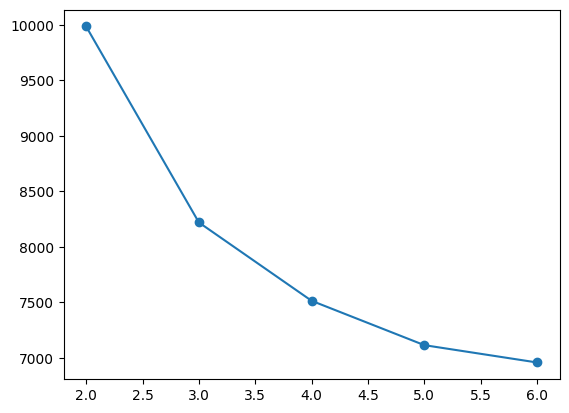

In [ ]:
# 1. Reorder the dataframe: Numerical first, then Categorical
# (Excluding caseid_new as it shouldn't be a feature)
num_features = ['w1_relate_duration_in2017_years', 'w1_weekly_sex_frequency']
cat_features = ['w1_section', 'w1_ppage', 'w1_ppgender', 'w1_ppeducat', 'w1_partyid7', 
                'w1_ppmsacat', 'w1_same_sex_couple', 'w1_ppincimp_cat', 
                'w1_q32', 'w1_max_relation_status', 'w1_q34', 'w1_q19', 'w1_married']

# Create a clean version with sorted columns
df_kproto = df_cluster[num_features + cat_features].copy()

# 2. Get the starting index of categorical columns
# Since we put numerical first, the index of the first categorical is len(num_features)
cat_idx = list(range(len(num_features), len(df_kproto.columns)))

# 3. Convert to values
data_matrix = df_kproto.values

# 4. Run Elbow Method
costs = []

for k in range(2, 7):
    print(f"Testing k={k}...")
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=1, verbose=0)
    kproto.fit(data_matrix, categorical=cat_idx)
    costs.append(kproto.cost_)

# Plot
import matplotlib.pyplot as plt
plt.plot(range(2, 7), costs, marker='o')
plt.show()


In [ ]:
# 1. Run the final model with k=3
k_best = 3
kproto_final = KPrototypes(n_clusters=k_best, init='Cao', n_init=1, verbose=1)
clusters = kproto_final.fit_predict(data_matrix, categorical=cat_idx)

# 2. Add the cluster labels back to the original cleaned dataframe
df_cluster['relationship_cluster'] = clusters

# 3. Quick check of the cluster sizes
print(df_cluster['relationship_cluster'].value_counts())


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 591, ncost: 9630.802791821177
Run: 1, iteration: 2/100, moves: 600, ncost: 8385.771365275888
Run: 1, iteration: 3/100, moves: 204, ncost: 8161.611180195511
Run: 1, iteration: 4/100, moves: 13, ncost: 8160.47491021124
Run: 1, iteration: 5/100, moves: 5, ncost: 8160.4625112810445
Run: 1, iteration: 6/100, moves: 0, ncost: 8160.4625112810445
relationship_cluster
0    1298
1    1023
2     436
Name: count, dtype: int64


In [ ]:
df_cluster.info()

<class 'pandas.DataFrame'>
Index: 2757 entries, 0 to 3509
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   caseid_new                       2757 non-null   int32  
 1   w1_section                       2757 non-null   str    
 2   w1_ppage                         2757 non-null   str    
 3   w1_ppgender                      2757 non-null   str    
 4   w1_ppeducat                      2757 non-null   str    
 5   w1_partyid7                      2757 non-null   str    
 6   w1_ppmsacat                      2757 non-null   str    
 7   w1_same_sex_couple               2757 non-null   str    
 8   w1_ppincimp_cat                  2757 non-null   str    
 9   w1_q32                           2757 non-null   str    
 10  w1_max_relation_status           2757 non-null   str    
 11  w1_weekly_sex_frequency          2757 non-null   float32
 12  w1_q34                           275

In [ ]:
df_cluster.head()

,caseid_new,w1_section,w1_ppage,w1_ppgender,w1_ppeducat,w1_partyid7,w1_ppmsacat,w1_same_sex_couple,w1_ppincimp_cat,w1_q32,w1_max_relation_status,w1_weekly_sex_frequency,w1_q34,w1_relate_duration_in2017_years,w1_q19,w1_married,relationship_cluster
0,53001,section 1: partnered adults,48,Female,High school,Not Strong Democrat,Non-Metro,NOT same-sex souple,$40K-$75K,"No, I did NOT meet [Partner Name] through the ...",married,0.025692,Excellent,-1.078318,Yes,yes,0
1,71609,section 1: partnered adults,68,Female,Some college,Leans Republican,Non-Metro,NOT same-sex souple,$40K-$75K,"No, I did NOT meet [Partner Name] through the ...",married,-0.679118,Excellent,1.878302,Yes,yes,1
2,106983,section 1: partnered adults,39,Male,Some college,Strong Democrat,Metro,NOT same-sex souple,$75K-$125K,"No, I did NOT meet [Partner Name] through the ...",married,0.025692,Excellent,-0.236433,Yes,yes,0
3,121759,section 1: partnered adults,54,Male,High school,Not Strong Republican,Metro,NOT same-sex souple,$75K-$125K,"No, I did NOT meet [Partner Name] through the ...",married,-0.467675,Excellent,0.354891,Yes,yes,1
5,164061,section 1: partnered adults,59,Male,Some college,Not Strong Republican,Metro,NOT same-sex souple,$75K-$125K,"No, I did NOT meet [Partner Name] through the ...",married,-0.679118,Excellent,0.124375,Yes,yes,0


In [ ]:
print(df_cluster['w1_q34'].unique())


<StringArray>
['Excellent', 'Good', 'Fair', 'Very Poor', 'Poor']
Length: 5, dtype: str


In [ ]:

# Transforming relationship quality to numeric scores for better interpretation
def get_cluster_profile(group):
    raw_group = df.loc[group.index]
    weights = raw_group['w1_weight_combo']
    
    profile = {}
    
    # 1. Duration of relationship (years) - weighted average
    profile['Years_Together'] = np.average(raw_group['w1_relate_duration_in2017_years'].fillna(0), weights=weights)
    
    # 2. Frequency of sex (number)
    valid_sex = raw_group['w1_weekly_sex_frequency'].notna()
    profile['Sex_Freq_Weekly'] = np.average(raw_group.loc[valid_sex, 'w1_weekly_sex_frequency'], weights=weights[valid_sex])
    
    # 3. Relationship quality (categorical) - convert to numeric scores and then average
    # Excellent=5, Good=4, Fair=3, Poor=2, Very Poor=1
    q_map = {'Excellent': 5, 'Good': 4, 'Fair': 3, 'Poor': 2, 'Very Poor': 1}
    q_scores = raw_group['w1_q34'].map(q_map).astype(float)
    profile['Happiness_Score'] = np.average(q_scores.dropna(), weights=weights[q_scores.notna()])
    
    # 4. Marriage rate (%)
    # In your file, this is a categorical column. We calculate the proportion of those who are 'yes' or '1'
    is_married = raw_group['w1_married'].astype(str).str.lower().str.contains('yes|1|married')
    profile['Marriage_Rate_%'] = np.average(is_married, weights=weights) * 100

    return pd.Series(profile)

interpretation_table = df_cluster.groupby('relationship_cluster').apply(get_cluster_profile)
print(interpretation_table.round(2))


                      Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster                                                     
0                              11.05             0.87             4.35   
1                              39.79             0.66             4.59   
2                              11.60             5.18             4.58   

                      Marriage_Rate_%  
relationship_cluster                   
0                               62.57  
1                               97.09  
2                               58.09  


In [ ]:
# 1. Checking the number of clusters for k=4
kproto_4 = KPrototypes(n_clusters=4, init='Cao', n_init=1, verbose=0)
clusters_4 = kproto_4.fit_predict(data_matrix, categorical=cat_idx)

# 2. New labels for k=4
df_cluster['relationship_cluster_k4'] = clusters_4

# 3. New profiles for k=4 (using the same function as before)
interpretation_table_k4 = df_cluster.groupby('relationship_cluster_k4').apply(get_cluster_profile)

print("--- Profiles for K=3 (Your Current Result) ---")
print(interpretation_table.round(2))

print("\n--- Profiles for K=4 (New Variant) ---")
print(interpretation_table_k4.round(2))

# 4. Group sizes for k=4
print("\nGroup sizes for k=4:")
print(df_cluster['relationship_cluster_k4'].value_counts())


--- Profiles for K=3 (Your Current Result) ---
                      Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster                                                     
0                              11.05             0.87             4.35   
1                              39.79             0.66             4.59   
2                              11.60             5.18             4.58   

                      Marriage_Rate_%  
relationship_cluster                   
0                               62.57  
1                               97.09  
2                               58.09  

--- Profiles for K=4 (New Variant) ---
                         Years_Together  Sex_Freq_Weekly  Happiness_Score  \
relationship_cluster_k4                                                     
0                                 16.52             0.85             4.45   
1                                  5.02             0.85             4.12   
2                                 

# Part 2 #

In [ ]:
print(f"Unique values in w3_relationship_end_combo:")
for x in df['w3_relationship_end_combo'].unique():
    print(x)

print(f"\nUnique values in w2_relationship_end:")
for x in df['w2_relationship_end'].unique():
    print(x)

Unique values in w3_relationship_end_combo:
no report of breakup or partner death
nan
Separated/ Broke up
Partner died
Got Divorced

Unique values in w2_relationship_end:
Divorce
no report of breakup or partner death
nan
Partner died
Separation or other breakup


In [ ]:
def identify_breakup(row):
    # Lists of strings that indicate a breakup based on your output
    breakup_labels = [
        'Separated/ Broke up', 
        'Got Divorced', 
        'Divorce', 
        'Separation or other breakup'
    ]
    
    # 1. Check for Breakups
    if (row['w2_relationship_end'] in breakup_labels) or \
       (row['w3_relationship_end_combo'] in breakup_labels):
        return 1
    
    # 2. Check for Death (Exclude these from the model)
    if (row['w2_relationship_end'] == 'Partner died') or \
       (row['w3_relationship_end_combo'] == 'Partner died'):
        return np.nan
    
    # 3. Check for "Still Together"
    # Only if they actually provided a report in Wave 3
    if row['w3_relationship_end_combo'] == 'no report of breakup or partner death':
        return 0
        
    return np.nan

# Apply to the main dataframe
df['target_breakup'] = df.apply(identify_breakup, axis=1)

# Add your K=4 cluster labels to the main dataframe
df['relationship_cluster'] = df_cluster['relationship_cluster_k4']

# Final Check
print("Distribution of Relationship Outcomes (2017-2022):")
print(df['target_breakup'].value_counts())


Distribution of Relationship Outcomes (2017-2022):
target_breakup
0.0    1480
1.0     237
Name: count, dtype: int64


/var/folders/6j/wxn98q7n083dpm833pdmj1v80000gn/T/ipykernel_30221/23976883.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target_breakup'] = df.apply(identify_breakup, axis=1)
/var/folders/6j/wxn98q7n083dpm833pdmj1v80000gn/T/ipykernel_30221/23976883.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['relationship_cluster'] = df_cluster['relationship_cluster_k4']


In [ ]:
# 1. Corrected feature list including the Meeting Method
features_for_model = [
    'relationship_cluster',           # From Part 1
    'w1_q24_met_online',              # WHERE they met (Online/Offline) - ADDED HERE
    'w1_ppage',                       # Age
    'w1_relate_duration_in2017_years',# Stability
    'w1_q34',                         # Initial Quality
    'w1_married',                     # Marital status
    'w1_ppeducat'                     # Education
]

# 2. Preparation of the dataset
# We keep weights to ensure the model learns from a representative sample
df_model = df[features_for_model + ['target_breakup', 'w3_attrition_adj_weight']].copy()

# Drop rows where we don't have a known target (2022 outcome)
df_model = df_model.dropna(subset=['target_breakup'])

# 3. Define which features are Categorical for CatBoost
# CatBoost is great because it handles these without "One-Hot Encoding"
cat_features = [
    'relationship_cluster', 
    'w1_q24_met_online', 
    'w1_q34', 
    'w1_married', 
    'w1_ppeducat'
]


In [ ]:
def get_breakup_rate(group):
    # Filter to ensure we only use rows where BOTH target and weight are present
    valid_data = group.dropna(subset=['target_breakup', 'w3_attrition_adj_weight'])
    
    if len(valid_data) == 0:
        return np.nan
    
    # Weighted average of 1s and 0s
    return np.average(valid_data['target_breakup'], weights=valid_data['w3_attrition_adj_weight']) * 100

breakup_report = df_model.groupby('relationship_cluster').apply(get_breakup_rate)
print("--- WEIGHTED BREAKUP RATE PER CLUSTER (%) ---")
print(breakup_report.round(2))


--- WEIGHTED BREAKUP RATE PER CLUSTER (%) ---
relationship_cluster
0.0    10.54
1.0    55.87
2.0    24.48
3.0     1.11
dtype: float64


In [ ]:

# 1. Clean the data - drop rows with missing target or weights
df_final = df_model.dropna(subset=['target_breakup', 'w3_attrition_adj_weight']).copy()

# 2. Define features
feature_cols = [
    'relationship_cluster', 
    'w1_q24_met_online', 
    'w1_ppage', 
    'w1_relate_duration_in2017_years', 
    'w1_q34', 
    'w1_married', 
    'w1_ppeducat'
]

# 3. CRITICAL FIX: Force all Categorical features to be strings using list comprehension
# This effectively kills all Pandas Categorical/NaN objects
cat_features = ['relationship_cluster', 'w1_q24_met_online', 'w1_ppage', 'w1_q34', 'w1_married', 'w1_ppeducat']

for col in cat_features:
    # Convert every value to string individually and handle hidden 'nan'
    df_final[col] = [str(val) if (val is not None and str(val) != 'nan') else "Unknown" for val in df_final[col]]

# 4. Prepare X, y and Weights
X = df_final[feature_cols]
y = df_final['target_breakup'].astype(int)
weights = df_final['w3_attrition_adj_weight']

# Identify categorical indices
cat_indices = [X.columns.get_loc(col) for col in cat_features]

# 5. Train/Test Split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

# 6. Final Model Fit
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_indices,
    verbose=100
)

model.fit(X_train, y_train, sample_weight=w_train, eval_set=(X_test, y_test))

# 7. Print Importance
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': model.get_feature_importance()})
print(feat_imp.sort_values(by='importance', ascending=False))


0:	learn: 0.6432496	test: 0.6436810	best: 0.6436810 (0)	total: 52.2ms	remaining: 26.1s
100:	learn: 0.1651628	test: 0.3265525	best: 0.3146586 (39)	total: 326ms	remaining: 1.29s
200:	learn: 0.1075355	test: 0.3346314	best: 0.3146586 (39)	total: 573ms	remaining: 852ms
300:	learn: 0.0807736	test: 0.3454905	best: 0.3146586 (39)	total: 914ms	remaining: 604ms
400:	learn: 0.0637696	test: 0.3537608	best: 0.3146586 (39)	total: 1.39s	remaining: 342ms
499:	learn: 0.0528570	test: 0.3593673	best: 0.3146586 (39)	total: 1.7s	remaining: 0us

bestTest = 0.3146586016
bestIteration = 39

Shrink model to first 40 iterations.
                           feature  importance
0             relationship_cluster   29.574828
5                       w1_married   21.011360
4                           w1_q34   18.348804
3  w1_relate_duration_in2017_years   12.901248
1                w1_q24_met_online    7.221981
6                      w1_ppeducat    6.995729
2                         w1_ppage    3.946050


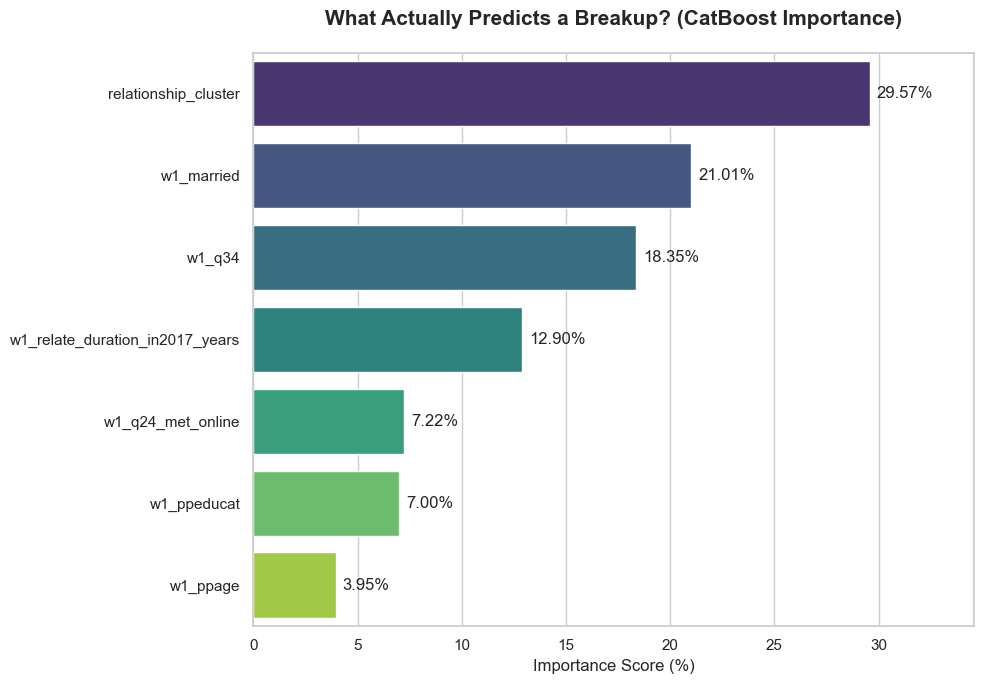

In [ ]:

# 1. Pull importance directly from your trained CatBoost model
# This ensures that if you re-run the model, the chart updates automatically
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
})

# Sort the values for a clean horizontal bar chart
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 2. Setup the visual style
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# 3. Build the plot
# Fixed: Assigning 'Feature' to 'hue' and setting legend=False to remove the warning
plot = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_imp_df, 
    hue='Feature',
    palette='viridis',
    legend=False
)

# 4. Add data labels (the actual % numbers) on the bars
for i in plot.containers:
    plot.bar_label(i, fmt='%.2f%%', padding=5)

# 5. Formatting
plt.title('What Actually Predicts a Breakup? (CatBoost Importance)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Importance Score (%)', fontsize=12)
plt.ylabel('') # Clean up the Y axis label
plt.xlim(0, feat_imp_df['Importance'].max() + 5) # Dynamically set X-limit

plt.tight_layout()

# 6. Save for your presentation
plt.savefig('okcupid_feature_importance_dynamic.png', dpi=300)
plt.show()
